# Candlesticks — parameter combinations

Playground walkthrough of the `Candlesticks` scheme kwargs: the color params (`color`, `colorup`/`colordn`) declare an atomic palette; `hollow` (tri-state) and `use_prev_close` are mode flags on top. Taxonomy and rationale in `notes/candlestick-styles.md`.

In [21]:
from mplchart.chart import Chart
from mplchart.primitives import Candlesticks
from mplchart.samples import sample_prices

prices = sample_prices().tail(60)
prices.tail()

,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


In [22]:
def show_candles(prices, title, **kwargs):
    """Plot one Candlesticks combination on a fresh chart."""
    chart = Chart(prices, figsize=(12, 4), title=title)
    chart.plot(Candlesticks(**kwargs))
    chart.show()

## Mono schemes

One color, direction shown by the fill: up-bars hollow (body filled with `axes.facecolor`), down-bars filled. `hollow=None` resolves to `True` here — fill is the mono palette's only direction channel.

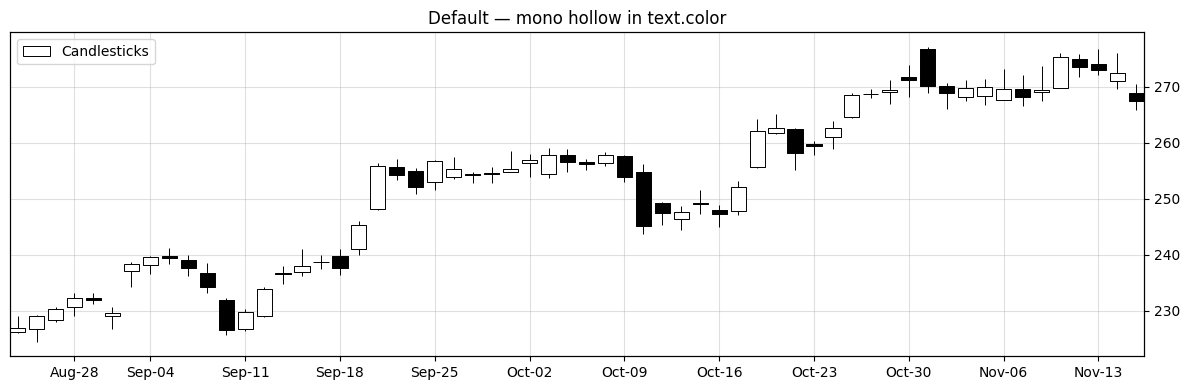

In [23]:
show_candles(prices, "Default — mono hollow in text.color")

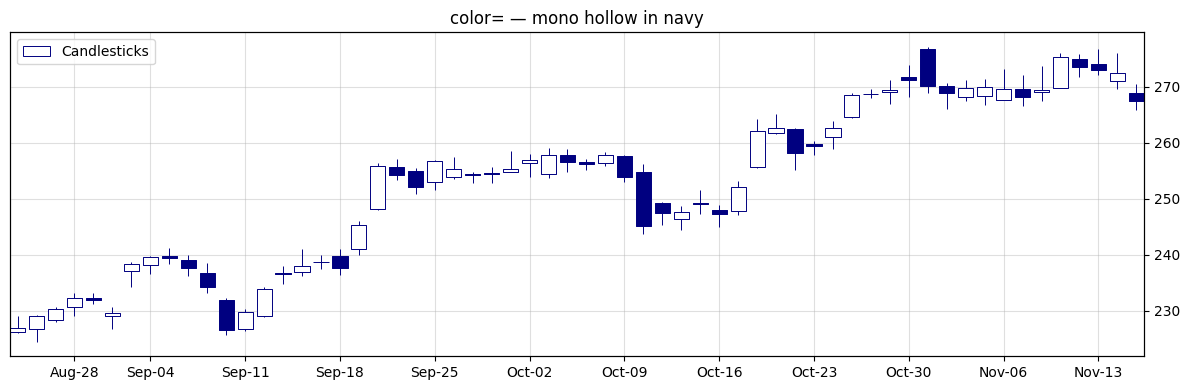

In [24]:
show_candles(prices, "color= — mono hollow in navy", color="navy")

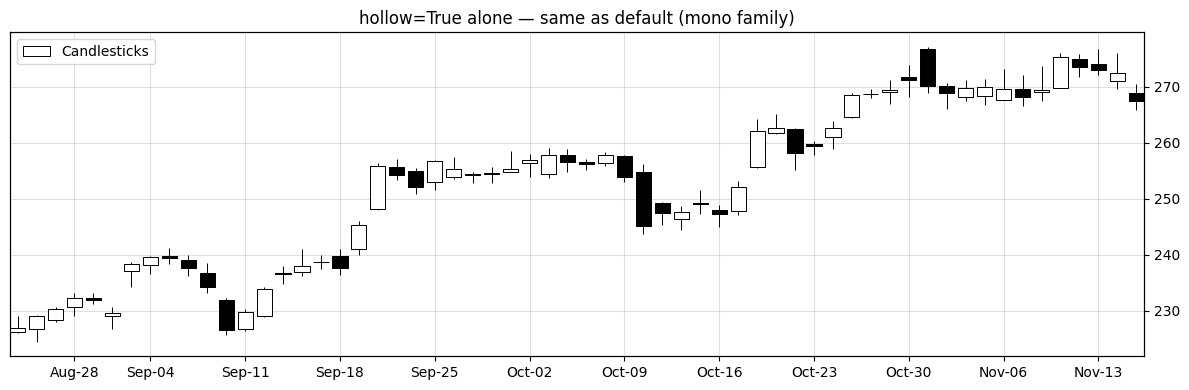

In [25]:
show_candles(prices, "hollow=True alone — same as default (mono family)", hollow=True)

## Bicolor schemes

`colorup`/`colordn` carry direction, so the fill is free: `hollow=None` resolves to `False` (filled convention), `hollow=True` gives colored hollow (TradingView hollow candles).

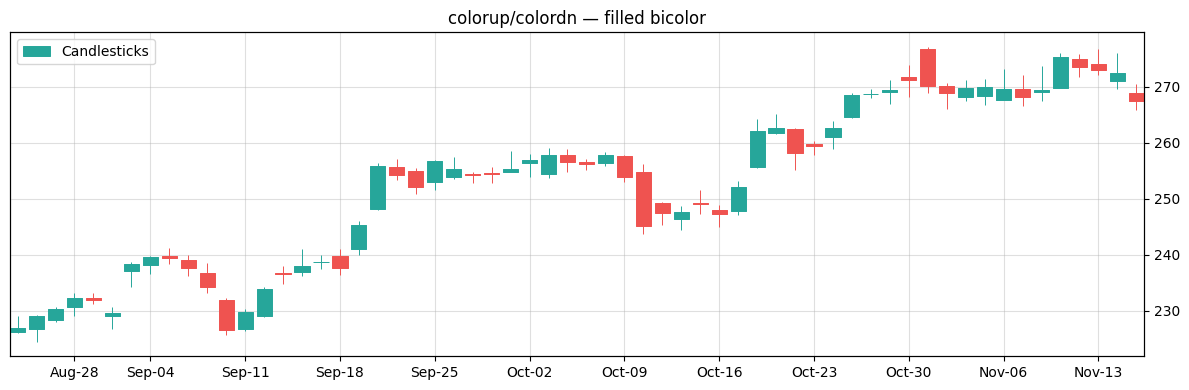

In [26]:
show_candles(prices, "colorup/colordn — filled bicolor",
             colorup="#26a69a", colordn="#ef5350")

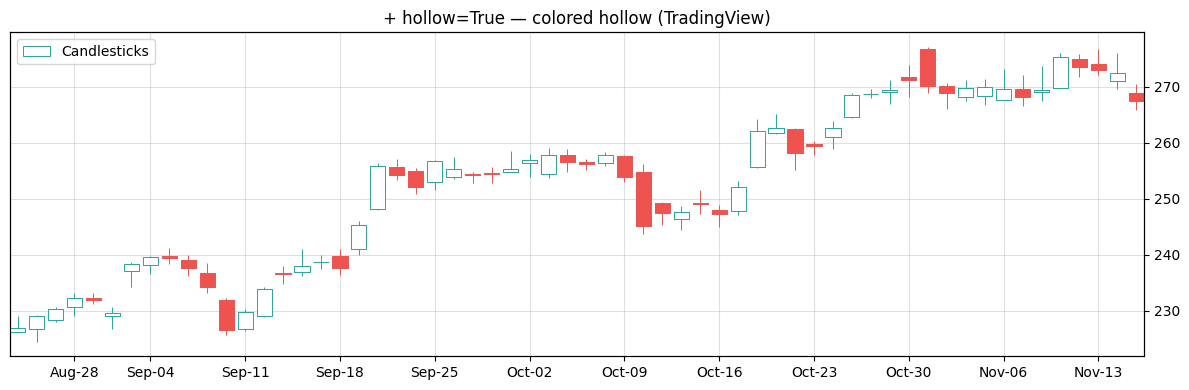

In [27]:
show_candles(prices, "+ hollow=True — colored hollow (TradingView)",
             colorup="#26a69a", colordn="#ef5350", hollow=True)

## Interbar coloring

`use_prev_close=True` colors by close vs previous close (interbar) while the fill flag stays intrabar (close vs open) — the two criteria are independent. Hollow × interbar is the StockCharts look.

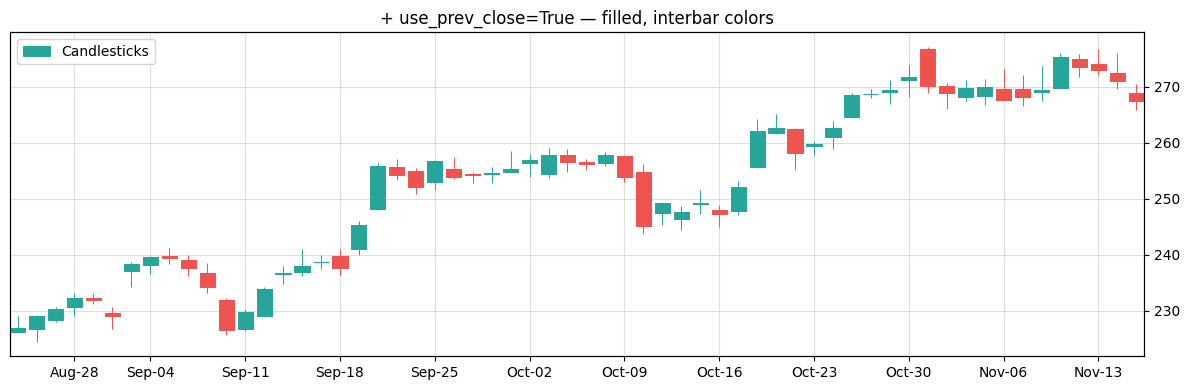

In [28]:
show_candles(prices, "+ use_prev_close=True — filled, interbar colors",
             colorup="#26a69a", colordn="#ef5350", use_prev_close=True)

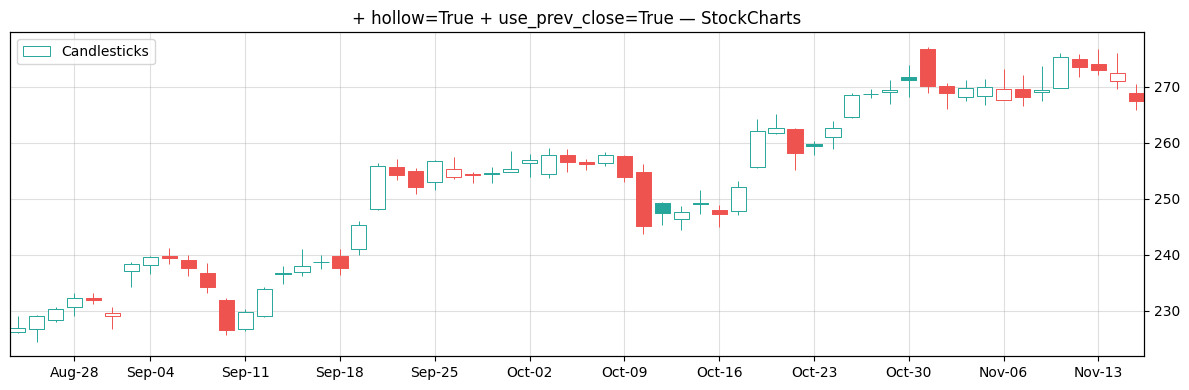

In [29]:
show_candles(prices, "+ hollow=True + use_prev_close=True — StockCharts",
             colorup="#26a69a", colordn="#ef5350", hollow=True, use_prev_close=True)

## Invalid combinations

Consistency checks are params-only — params express intent, and settings/defaults bend to the params, never the reverse. Competing schemes raise at construction; an explicit mono `color=` combined with a flag that needs two colors raises at plot time. Bare flags with no color kwargs (default mode) always render — the chart may look odd (e.g. `hollow=False` alone gives direction-blind filled candles), but it comes out.

In [30]:
import matplotlib.pyplot as plt

invalid = [
    dict(color="navy", colorup="green"),      # competing schemes
    dict(color="navy", use_prev_close=True),  # interbar criterion is mono-moot
    dict(color="navy", hollow=False),         # mono filled is direction-blind
]

for kwargs in invalid:
    try:
        chart = Chart(prices, figsize=(12, 4))
        chart.plot(Candlesticks(**kwargs))
        print(f"{kwargs} -> no error!")
    except ValueError as ex:
        print(f"{kwargs} -> ValueError: {ex}")
    finally:
        plt.close("all")

{'color': 'navy', 'colorup': 'green'} -> ValueError: Cannot pass color together with colorup/colordn!
{'color': 'navy', 'use_prev_close': True} -> ValueError: use_prev_close requires colorup/colordn!
{'color': 'navy', 'hollow': False} -> ValueError: Mono candles need hollow to show direction!
